# MITGCM Mixed Layer Depth Analysis (along a transect)

**Purpose**: Code for computing the mixed layer depth along the CalCOFI line 80 transect. 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
from autocorr import compute_autocorr_optimize, compute_decor_scale_optimize
from lsf import detrend
from ocean_analysis import compute_mld
from plotScaleAnalysis import month_fmt, add_freq_marker

Set data analysis parameters

In [3]:
# Set time and space parameters   
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/temporal/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs_server/mitgcm/scale_analysis/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
fontsize = 16

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
fontsize = 15
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

Load mitgcm data netcdf files 

In [4]:
#--- MITgcm Data ---# 
filename = PATH + "mitgcm_intermediate_data_TSD_hrly_transect_profiles.nc"
nc = Dataset(filename, 'r')

# Extract data variables
depth = nc.variables['depth'][:]
lon   = nc.variables['LON'][:]
lat   = nc.variables['LAT'][:]
dist  = nc.variables['DIST'][:]     
time  =  num2date(nc.variables['time'][:], nc.variables['time'].units)
data = nc.variables['SIG'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

# Flip the distance axis of the data array to match the orientation of the distance coordinates (increasing from left to right)
lon = lon[::-1]
lat = lat[::-1]
data = data[::-1,:,:]

Set the locations of each cce mooring

In [5]:
#--- CCE 1 ---# 
lon1 = -122.52233 
lat1 = 33.457

#--- CCE 2 ---# 
lon2 = -120.8042 
lat2 = 34.3075

#--- CCE 3 ---# 
lon3 = -120.53825701527784
lat3 = 34.44825228022894

#--- Shore ---# 
lon_shore = -120.483310
lat_shore = 34.482942

Compute the mixed layer depth as a function of time for each mooring location

In [6]:
# Set parameters
n_dist, n_time, n_depth = data.shape
phi = 100  # Units: J/m^2
g = 9.81   # Units: m/s^2

# Initialize arrays 
mld_PE     = np.ma.masked_all((n_dist, n_time))

# Loop over moorings 
for idist in range(n_dist):

    # Print state for ith mooring
    print(f'Computing MLD for mooring {idist+1}/{data.shape[0]} ...')
    
    # Loop over time
    for it in range(n_time):

        # Extract density profile at this mooring and time
        rho_prof = data[idist, it, :]
        
        # Skip fully masked profiles
        if rho_prof.mask.all():
            continue
        
        # Compute MLD using the potential energy anomaly method
        mld_PE[idist, it]     = compute_mld(abs(depth), density=rho_prof, method='potential_energy', phi=200)

# Mask invalid or missing values
mld_PE     = np.ma.masked_invalid(mld_PE)

# Compute the mean variance in the mixed layer depth at each mooring site
mld_m = np.ma.mean(mld_PE,axis=1)
mld_var = np.ma.var(mld_PE,axis=1,ddof=1)

Computing MLD for mooring 1/184 ...
Computing MLD for mooring 2/184 ...
Computing MLD for mooring 3/184 ...
Computing MLD for mooring 4/184 ...
Computing MLD for mooring 5/184 ...
Computing MLD for mooring 6/184 ...
Computing MLD for mooring 7/184 ...
Computing MLD for mooring 8/184 ...
Computing MLD for mooring 9/184 ...
Computing MLD for mooring 10/184 ...
Computing MLD for mooring 11/184 ...
Computing MLD for mooring 12/184 ...
Computing MLD for mooring 13/184 ...
Computing MLD for mooring 14/184 ...
Computing MLD for mooring 15/184 ...
Computing MLD for mooring 16/184 ...
Computing MLD for mooring 17/184 ...
Computing MLD for mooring 18/184 ...
Computing MLD for mooring 19/184 ...
Computing MLD for mooring 20/184 ...
Computing MLD for mooring 21/184 ...
Computing MLD for mooring 22/184 ...
Computing MLD for mooring 23/184 ...
Computing MLD for mooring 24/184 ...
Computing MLD for mooring 25/184 ...
Computing MLD for mooring 26/184 ...
Computing MLD for mooring 27/184 ...
Computing 

Compute a monthly climatology of mixed layer depths

In [7]:
# Compute the elapsed time from beginning of time series (units: seconds)
t0 = time[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time])

# Convert time array to year and month integers
years  = np.array([t.year for t in time_dt])
months = np.array([t.month for t in time_dt])

# Combine into "year-month" unique identifiers (e.g., 202301 for Jan 2023)
yearmonth = years * 100 + months
unique_months = np.unique(yearmonth)

# Set time parameters
dt = 1*(60)*(60)                   # Spcifies the time interval. Units: seconds

# Preallocate masked arrays for results
mld_monthly_mean  = np.ma.masked_all((n_dist, len(unique_months)))
mld_monthly_var   = np.ma.masked_all((n_dist, len(unique_months)))
mld_monthly_std   = np.ma.masked_all((n_dist, len(unique_months)))
mld_monthly_stdm  = np.ma.masked_all((n_dist, len(unique_months)))
mld_monthly_stdv  = np.ma.masked_all((n_dist, len(unique_months)))
Lt_days           = np.ma.masked_all((n_dist, len(unique_months)))

# Loop over moorings and months
for idist in range(n_dist):
    for im, ym in enumerate(unique_months):

        # Select all time indices belonging to this month
        idx = np.where(yearmonth == ym)[0]
        if idx.size == 0:
            continue
        
        # Extract MLD values for that mooring and month
        vals = mld_PE[idist, idx]
        itime = time_elapsed[idx]

        # Skip if all masked
        if vals.mask.all():
            continue

        # Compute monthly mean and variance ignoring masked values
        mld_monthly_mean[idist, im] = np.ma.mean(vals)
        mld_monthly_var[idist, im]  = np.ma.var(vals,ddof=1)
        mld_monthly_std[idist, im]  = np.ma.std(vals,ddof=1)

        # Compute the decorrelation scale 
        vals_dt = detrend(vals, itime, mean = 0)
        autocorr, _, _, _, lag_time, _ = compute_autocorr_optimize(vals_dt, itime, len(itime), 'biased', 0)
        Lt = compute_decor_scale_optimize(autocorr,lag_time,dt,'unbiased',0)

        # Convert decorrelation scale to units of days
        Lt_days[idist,im] = Lt*(1/60)*(1/60)*(1/24)

        # Compute the number of degrees of freedom at each site
        T_days = dt*(1/60)*(1/60)*(1/24)
        n_d = Lt_days[idist,im]/T_days
        N_eff = len(itime)/n_d

        # Compute the standard error of the mean and variance
        mld_monthly_stdm[idist, im] = mld_monthly_std[idist, im] / np.sqrt(N_eff)
        mld_monthly_stdv[idist, im] = mld_monthly_var[idist, im] * np.sqrt(2/(N_eff-1))

# Create simple arrays of the corresponding (year, month)
month_years = unique_months // 100
month_nums  = unique_months % 100

# Combine into datetime objects (using the first day of each month)
monthly_time = np.array([
    datetime(int(y), int(m), 1) for y, m in zip(month_years, month_nums)
])

Compute the seasonally averaged mixed layer depth 

In [8]:
mld_PE_mean = np.mean(mld_PE,axis=1)
mld_PE_std  = np.std(mld_PE,ddof=1,axis=1)
mld_PE_var  = np.var(mld_PE,ddof=1,axis=1)

Plot the mixed layer climatology as a function of distance offshore

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_12268/2479748010.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['D','J','F','M','A','M','J','J','A','S','O','N','D','J','F','M','A','M','J','J','A','S','O','N','D'])


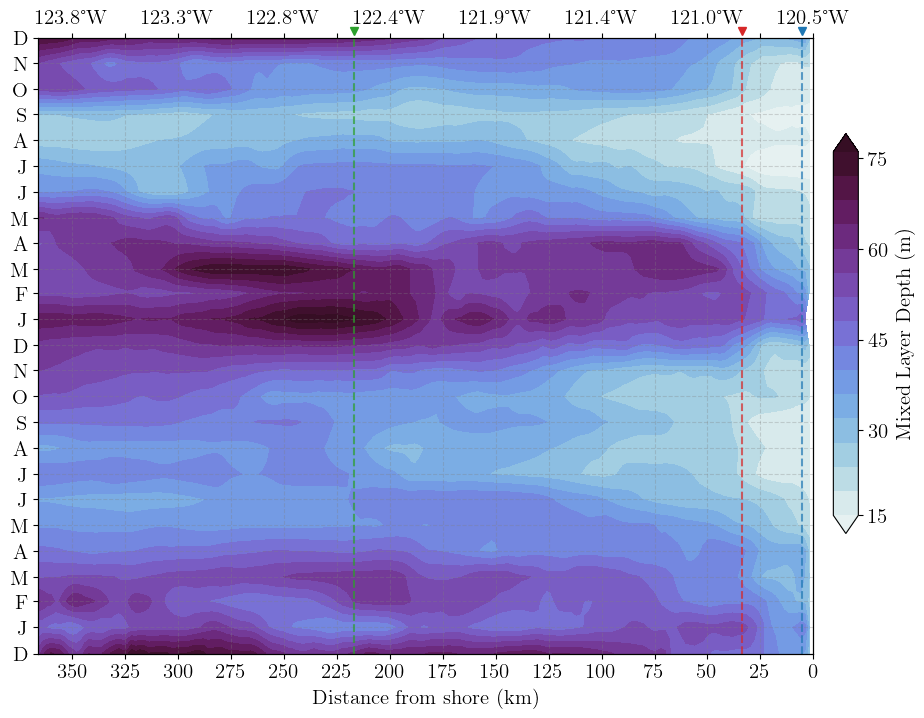

In [ ]:
# Set plotting parameters
label = r'Mixed Layer Depth (m)'
levels = np.arange(10,60,2)
cmap = cmo.dense

# Create figure
fig, ax = plt.subplots(figsize=(10,8))

# Plot mixed layer depth climatology
cf = ax.contourf(dist,monthly_time,mld_monthly_mean.T, levels=20, cmap=cmap, extend='both')

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_xticks(np.arange(0,350+25,25))
ax.invert_xaxis()
ax.yaxis.set_major_locator(mdates.MonthLocator())
ax.set_yticklabels(['D','J','F','M','A','M','J','J','A','S','O','N','D','J','F','M','A','M','J','J','A','S','O','N','D'])
#ax.yaxis.set_major_formatter(FuncFormatter(month_fmt))
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.92, 0.26, 0.025, 0.5])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.set_label(label)
cbar.set_ticks(np.arange(15,75+15,15))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.01, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.01, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.01, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Show plot 
plt.show()

# Save with high quality
figName = 'figS20.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_12268/1468987492.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['D','J','F','M','A','M','J','J','A','S','O','N','D','J','F','M','A','M','J','J','A','S','O','N','D'])


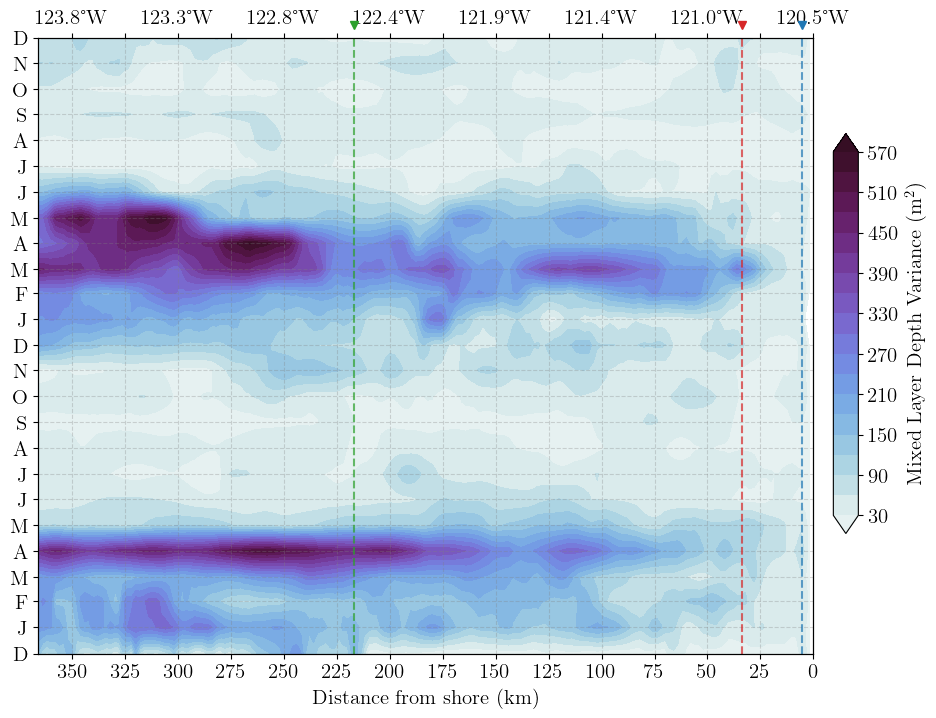

In [ ]:
# Set plotting parameters
label = r'Mixed Layer Depth Variance (m$^2$)'
levels = np.arange(10,60,2)
cmap = cmo.dense

# Create figure
fig, ax = plt.subplots(figsize=(10,8))

# Plot mixed layer depth climatology
cf = ax.contourf(dist,monthly_time,mld_monthly_var.T, levels=20, cmap=cmap, extend='both')

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_xticks(np.arange(0,350+25,25))
ax.invert_xaxis()
ax.yaxis.set_major_locator(mdates.MonthLocator())
ax.set_yticklabels(['D','J','F','M','A','M','J','J','A','S','O','N','D','J','F','M','A','M','J','J','A','S','O','N','D'])
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.92, 0.26, 0.025, 0.5])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.set_label(label)

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Show plot 
plt.show()

# Save with high quality
figName = 'figS21.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

Plot the seasonally average mixed layer depth 

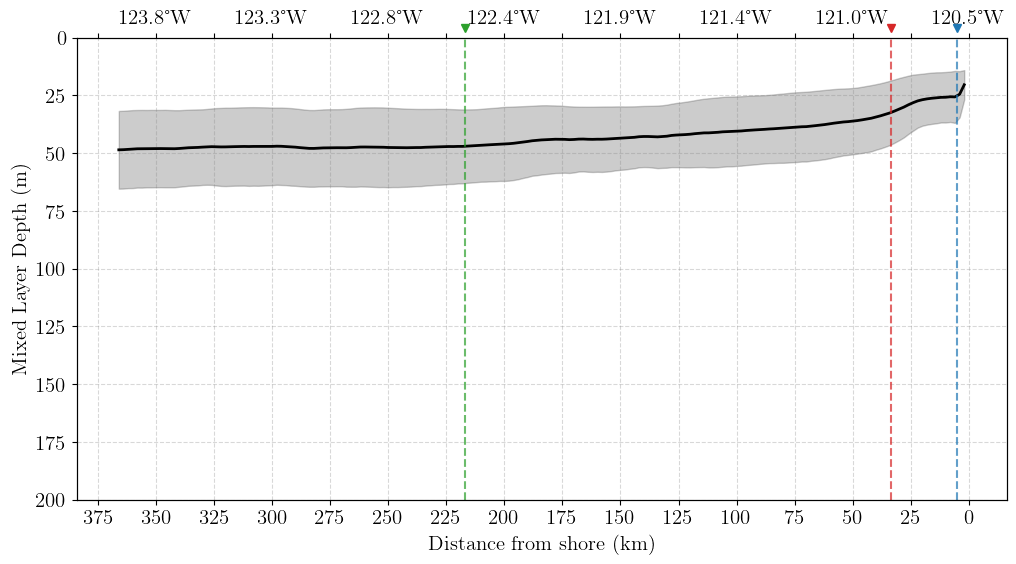

In [11]:
# Create figure 
fig, ax = plt.subplots(figsize=(12,6))

# Plot seasonally averaged mixed layer depth
ax.plot(dist,mld_PE_mean,'-k', lw=2,markersize=8)

# Plot the standard deviation 
ax.fill_between(dist, mld_PE_mean - mld_PE_std, mld_PE_mean + mld_PE_std, color='black', alpha=0.2)

# Set figure attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Mixed Layer Depth (m)')
ax.set_xticks(np.arange(0,375+25,25))
ax.set_ylim(0,200)
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Show plot 
plt.show()

Save data in a netcdf file

In [12]:
# Check if file exists, then delete it
file_mld_path = PATH + "mitgcm_transect_mld_climatology.npz"
if os.path.exists(file_mld_path):
    os.remove(file_mld_path)

# Set metadata
metadata = {
    'description': 'Mixed layer time series at stations along the CalCOFI line 80 transect. The mixed layer is computed using the potential energy method.',
    'source': 'MITgcm model output',
    'coordinates units': '1 hr'
}
    
# Save data arrays and metadata to a .npz file
np.savez(file_mld_path,
    mld               = mld_PE, 
    mld_monthly_mean  = mld_monthly_mean, 
    mld_monthly_var   = mld_monthly_var, 
    mld_monthly_stdm  = mld_monthly_stdm, 
    mld_monthly_stdv  = mld_monthly_stdv, 
    lon               = lon,
    lat               = lat,
    dist              = dist,
    time              = time_dt,
    time_monthly      = monthly_time,        # Units: months
    metadata          = metadata
    )